# 필요한 모듈 임포트

In [129]:
import numpy as np  # ndarray
import pandas as pd  # DataFrame
import matplotlib.pyplot as plt  # 시각화
import seaborn as sns  # 시각화, 예제 데이터셋

# 데이터셋 준비

In [2]:
tips = sns.load_dataset("tips")

In [3]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


# `matplotlib.pyplot` 모듈을 사용한 데이터 시각화

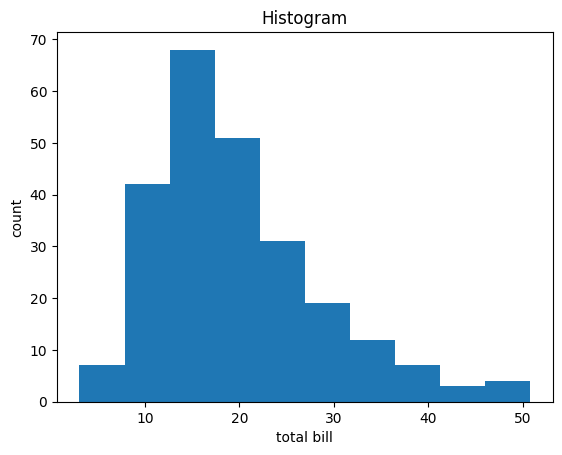

In [10]:
# 1. Figure 객체 생성
fig = plt.figure()

# 2. Figure 객체에 Axes 설정 - Subplot을 생성.
# axis = fig.add_subplot(1, 1, 1)  # add_subplot(nrows, ncols, index)
axis = fig.add_subplot(111)  # add_subplot(pos): "행/열/인덱스" 순서로 만들어진 3자리 정수.
#> add_subplot에서 인덱스는 1부터 시작!

# 3. Axis(축)에 그래프를 그림
axis.hist(x=tips.total_bill)  # 히스토그램

# 4. 그래프 옵션 설정.
axis.set_title("Histogram")
axis.set_xlabel("total bill")
axis.set_ylabel("count")

# 5. 그래프 보여주기.
plt.show()

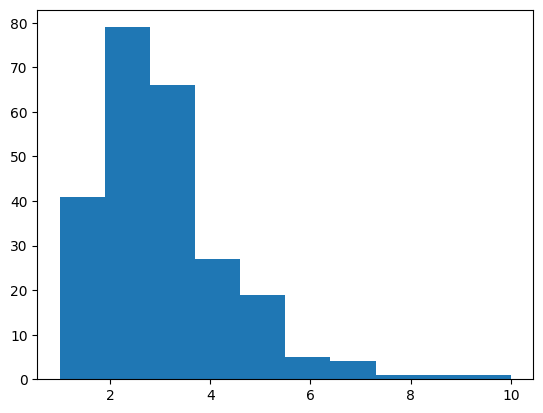

In [11]:
# 1. Figure, Axes 객체 생성
fig, axis = plt.subplots()  # nrows, ncols 파라미터 기본값은 1.

# 2. 그래프 그림.
axis.hist(x=tips.tip)

# 3. 그래프 옵션 설정.
axis.set_title("Histogram")
axis.set_xlabel("tip")
axis.set_ylabel("count")

# 4. 그래프 보여주기.
plt.show()

1개의 Figure에 1개의 Axes(Subplot)만 있는 경우에는 `matplotlib.pyplot` 모듈의 top-level 함수(plot, scatter, hist, ...)를 사용해서 간단히 그래프를 그릴 수 있음.

top-level 함수를 사용할 때는 Figure, Axes 객체를 생성하는 코드를 작성할 필요가 없음.

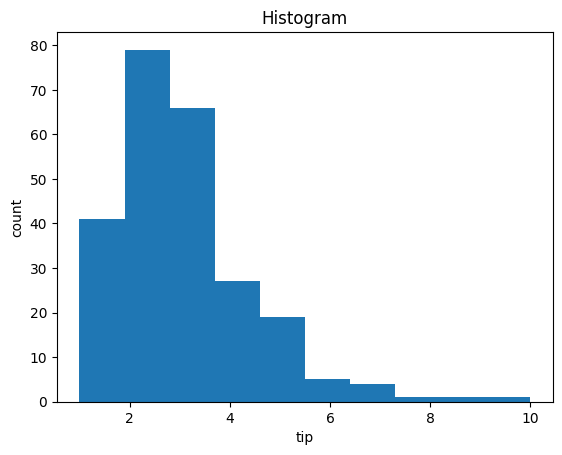

In [15]:
# Figure 객체 생성, Axes 객체 생성, 히스토그램 그리기.
plt.hist(x=tips.tip)

# 그래프 옵션 설정.
plt.title("Histogram")
plt.xlabel("tip")
plt.ylabel("count")

# 그래프 보여주기
plt.show()

# Box Plot(상자 그림)

연속형 자료(숫자 타입 데이터)의 기술 통계량(최솟값, 25%, 중앙값, 75%, 최댓값)과 이상치(outlier)를 상자 모양으로 시각화한 그래프.

In [18]:
tips.total_bill.describe()

,total_bill
count,244.000000
mean,19.785943
std,8.902412
min,3.070000
25%,13.347500
50%,17.795000
75%,24.127500
max,50.810000


<function matplotlib.pyplot.show(close=None, block=None)>

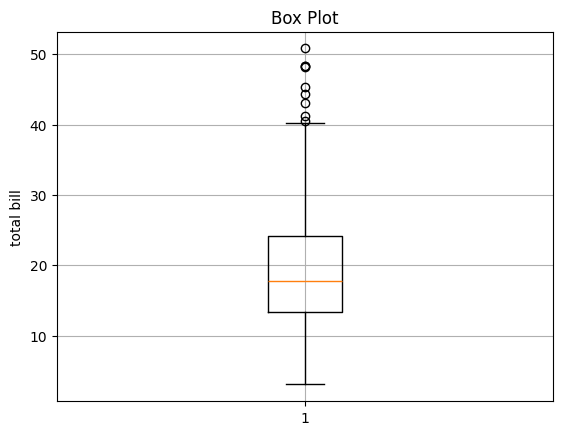

In [23]:
plt.boxplot(x=tips.total_bill)
plt.ylabel('total bill')
plt.title('Box Plot')
plt.grid()
plt.showb

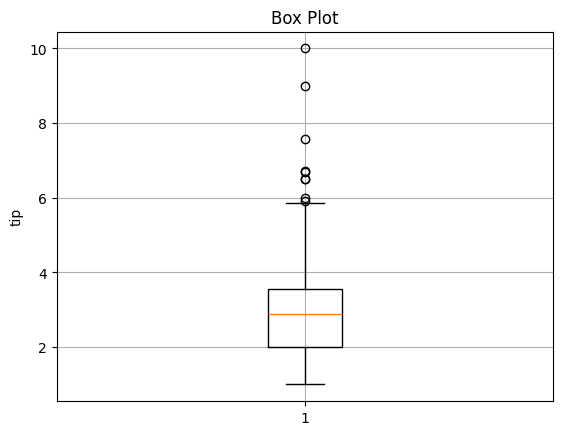

In [25]:
# 팁 box plot
plt.boxplot(x=tips.tip)
plt.ylabel('tip')
plt.title('Box Plot')
plt.grid()
plt.show()

In [26]:
tips.tip.describe()

,tip
count,244.000000
mean,2.998279
std,1.383638
min,1.000000
25%,2.000000
50%,2.900000
75%,3.562500
max,10.000000


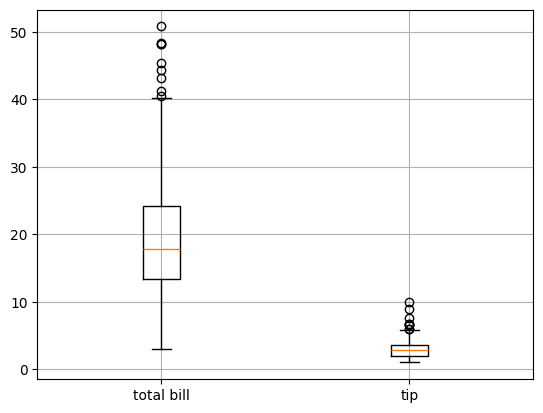

In [29]:
plt.boxplot(x=[tips.total_bill, tips.tip], tick_labels=['total bill', 'tip'])
plt.grid()
plt.show()

1개의 Figure 안에 2개의 Axes(Subplot)을 좌/우로 배치해서, 왼쪽에는 total_bill의 box plot을, 오른쪽에는 tip의 box plot을 시각화.

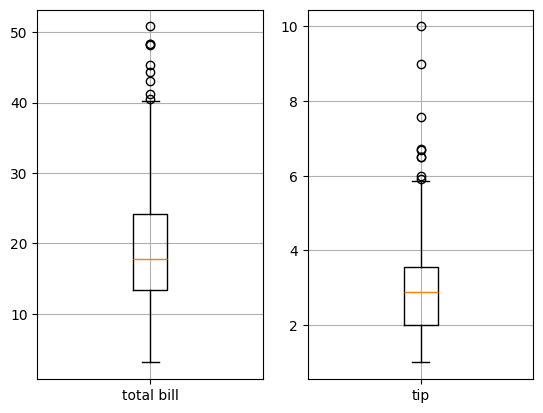

In [34]:
fig = plt.figure()  # Figure 객체 생성

ax1 = fig.add_subplot(1, 2, 1)  # Axes 객체 생성
ax2 = fig.add_subplot(122)  # Axes 객체 생성

ax1.boxplot(x=tips.total_bill, tick_labels=["total bill"])  # 첫번째 Axes에 box plot을 시각화
ax2.boxplot(x=tips.tip, tick_labels=["tip"])  # 두번째 Axes에 box plot을 시각화.

ax1.grid()
ax2.grid()

plt.show()

[<Axes: > <Axes: >]
<class 'numpy.ndarray'>


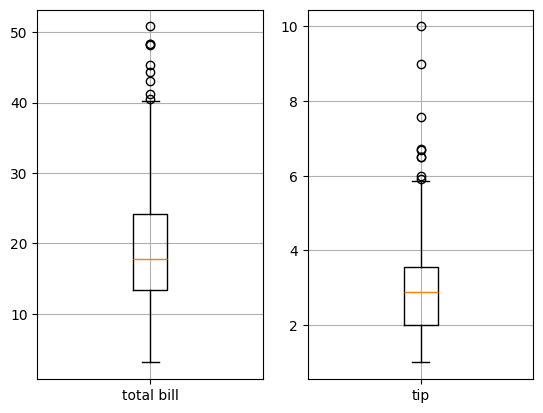

In [42]:
fig, axes = plt.subplots(nrows=1, ncols=2)
print(axes)  # axes: Axes 클래스 객체(들)을 저장하고 있는 배열(ndarray)
print(type(axes))

axes[0].boxplot(x=tips.total_bill, tick_labels=["total bill"])
axes[1].boxplot(x=tips.tip, tick_labels=['tip'])

axes[0].grid()
axes[1].grid()

plt.show()

## 성별 팁의 box plot

*   남성(Male) tip의 기술 통계량 출력
*   여성(Female) tip의 기술 통계량 출력
*   성별 tip의 box plot을 1개의 Axes에 시각화

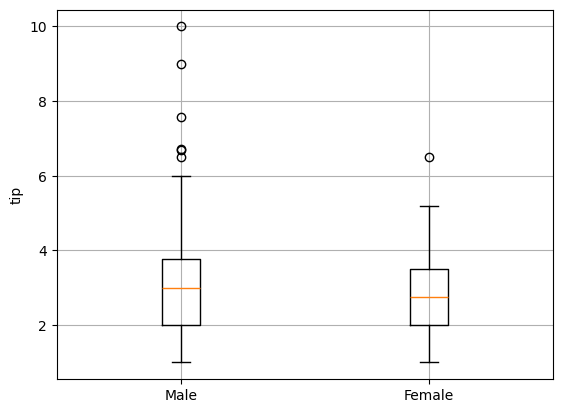

In [83]:
# 강사님 답안

male_tip = tips[tips.sex == "Male"].tip
female_tip = tips[tips.sex == "Female"].tip

male_tip.describe()
female_tip.describe()

plt.boxplot(x=[male_tip, female_tip], tick_labels=["Male", "Female"])
plt.ylabel("tip")
plt.grid()
plt.show()

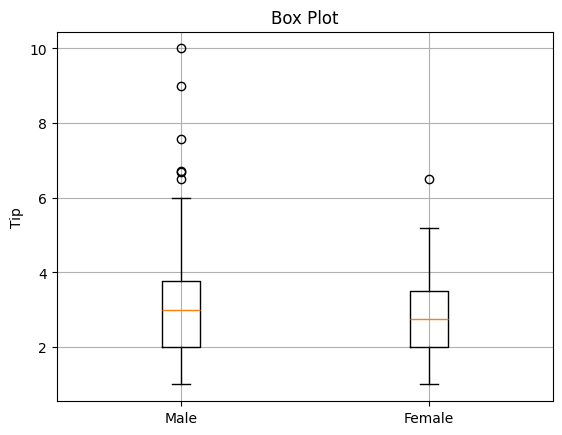

In [51]:
Male_tips = tips[tips.sex == "Male"]
Fem_tips = tips[tips.sex == "Female"]

plt.boxplot(x=[Male_tips.tip, Fem_tips.tip], tick_labels=['Male', 'Female'])
plt.title("Box Plot")
plt.ylabel("Tip")
plt.grid()
plt.show()

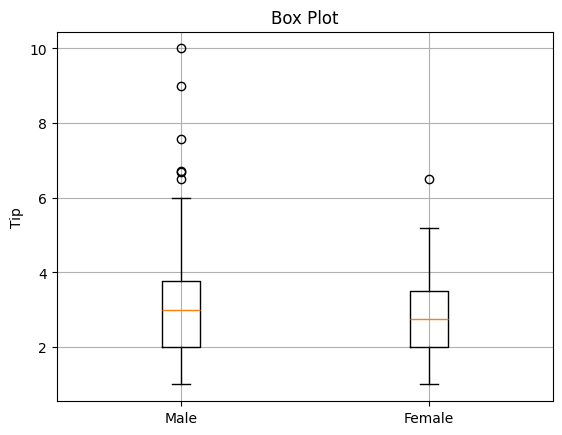

In [73]:
Male_tips = tips[tips.sex == "Male"]
Fem_tips = tips[tips.sex == "Female"]

fig = plt.figure()
ax_gender = fig.add_subplot(111)
ax_gender.boxplot(x=[Male_tips.tip, Fem_tips.tip], tick_labels=["Male", "Female"])
ax_gender.set_title("Box Plot")
ax_gender.set_ylabel("Tip")
ax_gender.grid()
plt.show()

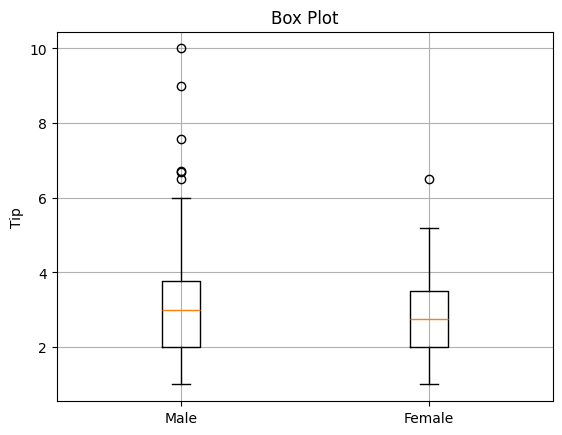

In [75]:
Male_tips = tips[tips.sex == "Male"]
Fem_tips = tips[tips.sex == "Female"]

fig, ax_gender = plt.subplots()
ax_gender.boxplot(x=[Male_tips.tip, Fem_tips.tip], tick_labels=["Male", "Female"])
ax_gender.set_title("Box Plot")
ax_gender.set_ylabel("Tip")
ax_gender.grid()
plt.show()

## 시간(Lunch, Dinner)별 tip의 box plot

In [ ]:
# 강사님 답안
tips.time.unique()  # tips 데이터프레임에서 time 컬럼의 유일한(중복되지 않는) 값들.
tips.time.cat.categories  # time 카테고리(범주) 타입 변수의 카테고리(범주)들.

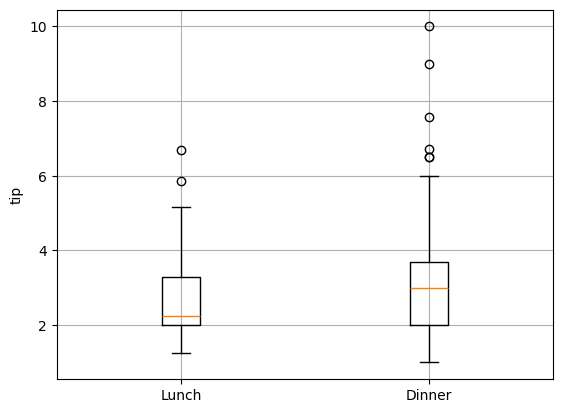

In [88]:
# 강사님 답안
lunch_tip = tips[tips.time == "Lunch"].tip
lunch_tip.describe()

dinner_tip = tips[tips.time == "Dinner"].tip
dinner_tip.describe()

plt.boxplot(x=[lunch_tip, dinner_tip], tick_labels=["Lunch", "Dinner"])
plt.ylabel("tip")
plt.grid()
plt.show()

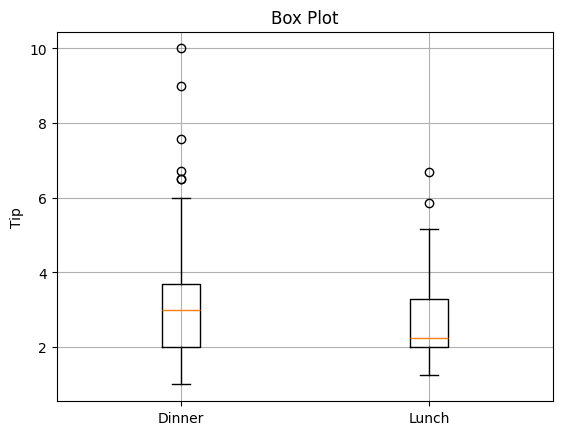

In [59]:
Dinner_tips = tips[tips.time == "Dinner"]
Lunch_tips = tips[tips.time == "Lunch"]

plt.boxplot(x=[Dinner_tips.tip, Lunch_tips.tip], tick_labels=["Dinner", "Lunch"])
plt.ylabel("Tip")
plt.title("Box Plot")
plt.grid()
plt.show()

## 요일(Thur, Fri, Sat, Sun)별 tip의 box plot

In [90]:
# 강사님 답안
tips.day.unique()

for d in tips.day.unique():
    print(d)

Sun
Sat
Thur
Fri


In [92]:
#
tips.day.cat.categories

for d in tips.day.cat.categories:
    print(d)

Thur
Fri
Sat
Sun


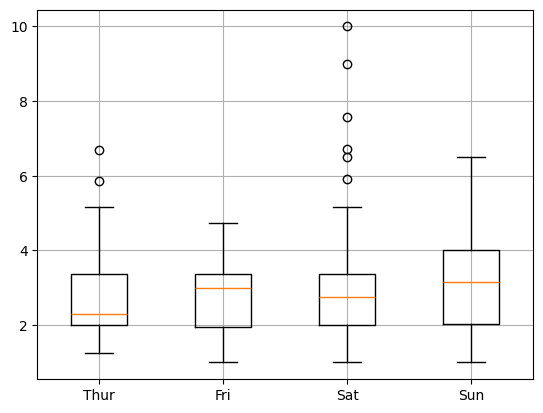

In [97]:
#
thur_tip = tips[tips.day == "Thur"].tip
fri_tip = tips[tips.day == "Fri"].tip
sat_tip = tips[tips.day == "Sat"].tip
sun_tip = tips[tips.day == "Sun"].tip

plt.boxplot(x=[thur_tip, fri_tip, sat_tip, sun_tip],
            tick_labels=tips.day.cat.categories)
plt.grid()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

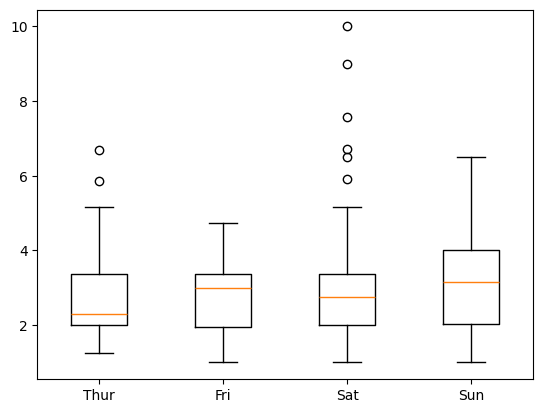

In [100]:
#
day_category = tips.day.cat.categories  # 요일 카테고리(목/금/토/일)
data = []  # 요일별 팁의 컬럼을 저장하기 위한 빈리스트
for d in day_category:
    tip_by_day = tips[tips.day == d].tip
    data.append(tip_by_day)

plt.boxplot(x=data, tick_labels=day_category)
plt.show

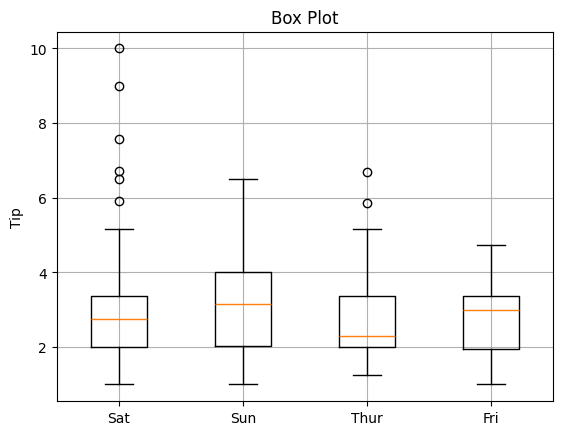

In [64]:
Sat_tips = tips[tips.day == "Sat"]
Sun_tips = tips[tips.day == "Sun"]
Thur_tips = tips[tips.day == "Thur"]
Fri_tips = tips[tips.day == "Fri"]

plt.boxplot(
    x=[Sat_tips.tip, Sun_tips.tip, Thur_tips.tip, Fri_tips.tip],
    tick_labels=["Sat", "Sun", "Thur", "Fri"]
)
plt.grid()
plt.title("Box Plot")
plt.ylabel("Tip")
plt.show()

# Histogram(히스토그램)

연속형 자료(숫자 타입 데이터)를 구간으로 나눠서 그 구간 안에 포함된 자료의 개수를 막대로 표현한 그래프.

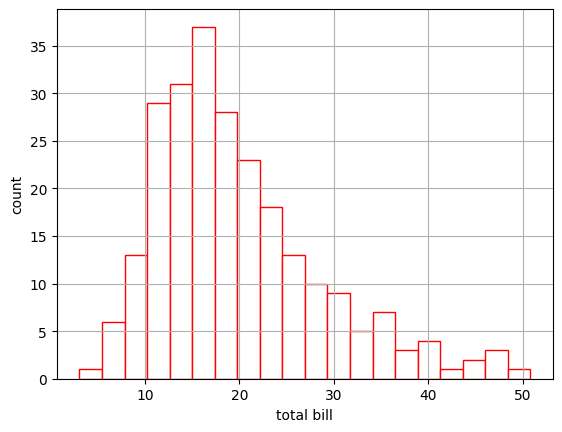

In [114]:
plt.hist(x=tips.total_bill,  # x: 히스토그램을 그리기 위한 연속형 자료(컬럼, 변수).
         bins=20,            # bins: 막대 개수 또는 구간.
         color="white",      # color: 막대 내부를 채우는 색깔.
         edgecolor="red")    # edgecolor: 막대 테두리 색깔.
plt.grid()
plt.xlabel("total bill")
plt.ylabel("count")
plt.show()

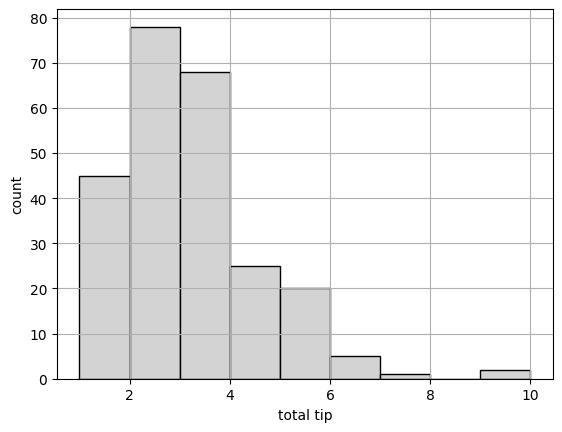

In [131]:
# tip의 히스토그램
plt.hist(x=tips.tip, bins=np.arange(1, 11), color="LightGray", edgecolor="black")
plt.grid()
plt.xlabel("total tip")
plt.ylabel("count")
plt.show()

# Bar graph(막대 그래프)

카테고리(범주) 타입 변수(컬럼)의 빈도수를 막대로 표현한 그래프.

## 세로 막대 그래프(vertical bar graph)

In [137]:
gender_count = tips.sex.value_counts()
gender_count

,count
sex,
Male,157
Female,87


In [139]:
print(type(gender_count))  #> Series

<class 'pandas.core.series.Series'>


In [138]:
gender_count.values  #> 값(빈도수)들을 저장하고 있는 배열

array([157,  87])

In [140]:
gender_count.index  #> 인덱스를 저장하고 있는 배열

CategoricalIndex(['Male', 'Female'], categories=['Male', 'Female'], ordered=False, dtype='category', name='sex')

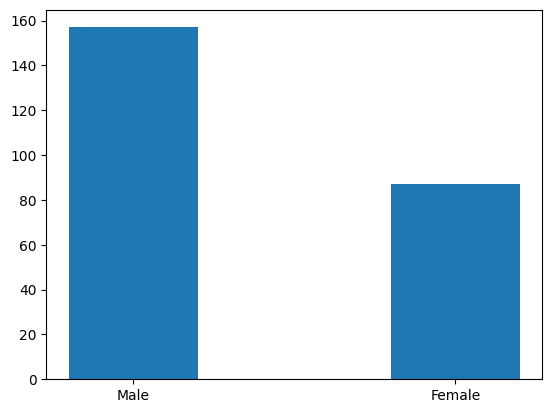

In [145]:
plt.bar(x=gender_count.index, height=gender_count.values, width=0.4)
plt.show()

## 가로 막대 그래프(horizontal bar graph)

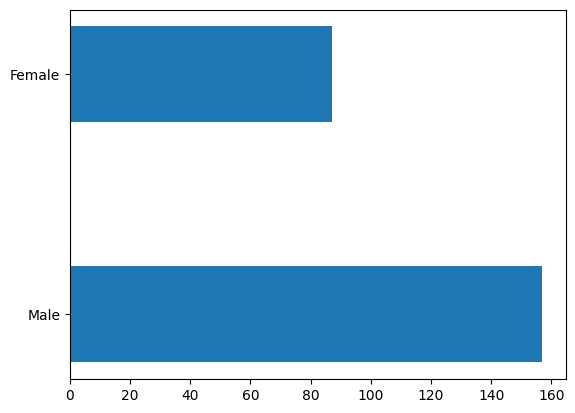

In [148]:
plt.barh(y=gender_count.index, width=gender_count.values, height=0.4)
plt.show()

# 그냥 푼 문제 채점하려고 만든 것

In [150]:
ls1 = [3, 4, 1, 4, 1, 1, 1, 2, 4, 2, 2, 1, 1, 4, 1, 1, 2, 1, 4, 2]
ls2 = [3, 2, 1, 4, 3, 1, 1, 2, 4, 2, 2, 1, 1, 4, 1, 1, 2, 3, 4, 3]

ls3 = [x == y for x, y in zip(ls1, ls2)]

[f"{x}. {y}" for x, y in zip(range(1, 21), ls3)]

['1. True',
 '2. False',
 '3. True',
 '4. True',
 '5. False',
 '6. True',
 '7. True',
 '8. True',
 '9. True',
 '10. True',
 '11. True',
 '12. True',
 '13. True',
 '14. True',
 '15. True',
 '16. True',
 '17. True',
 '18. False',
 '19. True',
 '20. False']

size의 빈도수를 세로 막대 그래프로 시각화

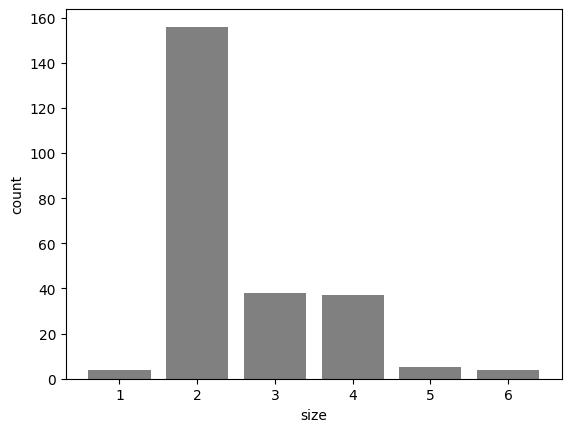

In [176]:
size_tips = tips["size"].value_counts().sort_index()
plt.bar(x=size_tips.index, height=size_tips.values, color="gray")
plt.xlabel("size")
plt.ylabel("count")
plt.show()

요일(day) 빈도수를 가로 막대 그래프로 시각화

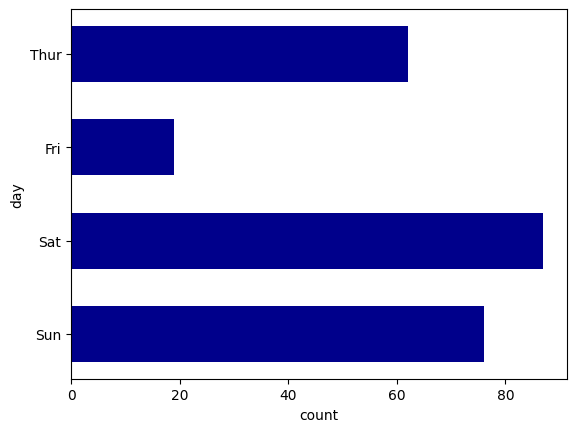

In [195]:
day_tips = tips.day.value_counts().sort_index(ascending=False)
plt.barh(y=day_tips.index, width=day_tips.values, height=0.6, color="darkblue")
plt.xlabel("count")
plt.ylabel("day")
plt.show()

*   4개의 Axes를 2x2 모양(nrows=2, ncols=2)으로 생성.
*   각각의 Axes에 성별 빈도수, 흡연여부 빈도수, 요일 빈도수, 시간 빈도수 (세로) 막대 그래프를 시각화.

In [197]:
# 강사님 답안
gender_count = tips.sex.value_counts()  # 성별 빈도수
smoker_count = tips.smoker.value_counts()  # 흡연여부 빈도수
day_count = tips.day.value_counts()  # 요일 빈도수
time_count = tips.time.value_counts()  # 시간 빈도수

[[<Axes: > <Axes: >]
 [<Axes: > <Axes: >]]


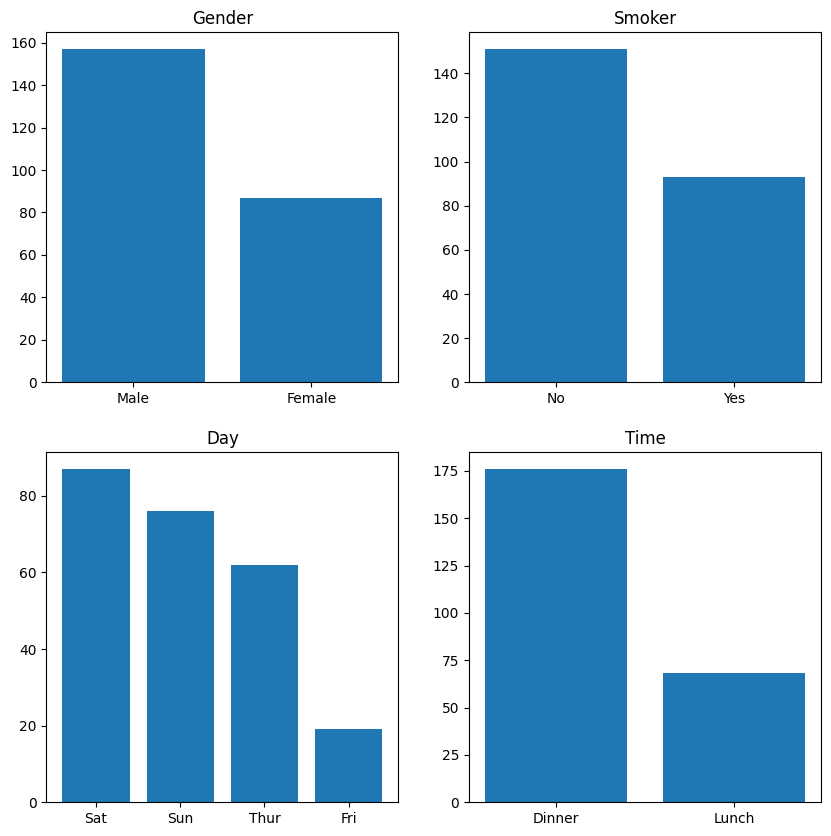

In [213]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
print(axes)  #> 2차원 배열

axes[0, 0].bar(x=gender_count.index, height=gender_count.values)
axes[0, 0].set_title("Gender")

axes[0, 1].bar(x=smoker_count.index, height=smoker_count.values)
axes[0, 1].set_title("Smoker")

axes[1, 0].bar(x=day_count.index, height=day_count.values)
axes[1, 0].set_title("Day")

axes[1, 1].bar(x=time_count.index, height=time_count.values)
axes[1, 1].set_title("Time")

plt.show()

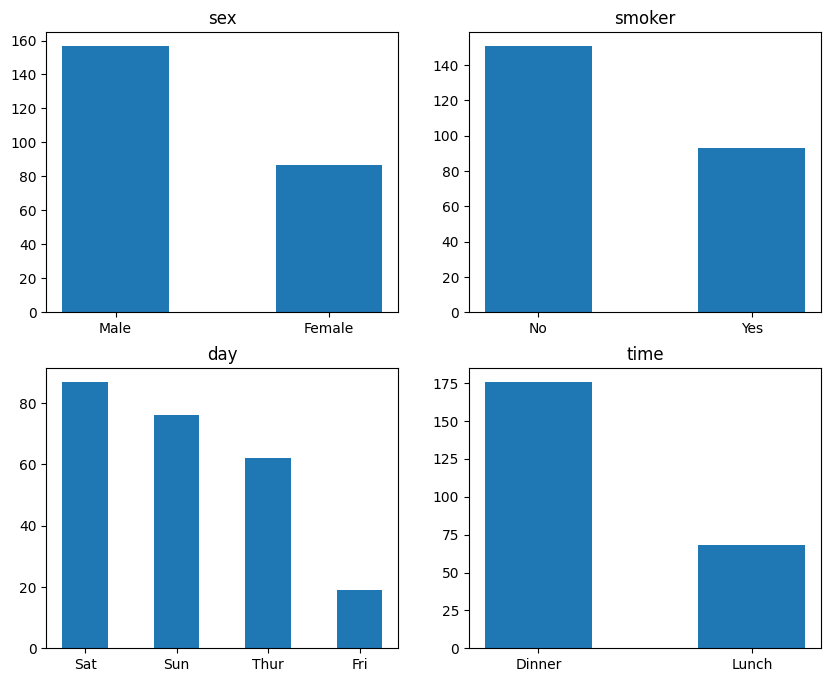

In [221]:
titles = [['sex', 'smoker'], ['day', 'time']]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
for i, row in enumerate(titles):
    for j, t in enumerate(row):
        # print(i, j, t)
        data = tips[t].value_counts()
        axes[i, j].bar(x=data.index, height=data.values, width=0.5)
        axes[i, j].set_title(t)

plt.show()